<a href="https://colab.research.google.com/github/Lorenasaquicoray/Applied-Machine-Learning/blob/main/Template_Matching_and_Similarity_Measures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Template Matching and Similarity Measures

Each of the items below will require you to perform a task and you will need to research how to accomplish those tasks. Just like ‘real world’ job tasks there is no textbook to guide you through all of the steps. There are however several resources you can use to help steer you through the lab, such as programming library documentation, Google, ChatGPT, etc.

You may complete the exercises as given below, or you may combine them all in a single code block. If you do the latter, please make it clear which exercise each portion of the code and each output correspond to.

In [ ]:
# you may find it useful to put import statements up here

import matplotlib.pyplot as plt
import numpy as np

## Part One

1. Create a plot using the python matplotlib library and plot two points (you decide their values).

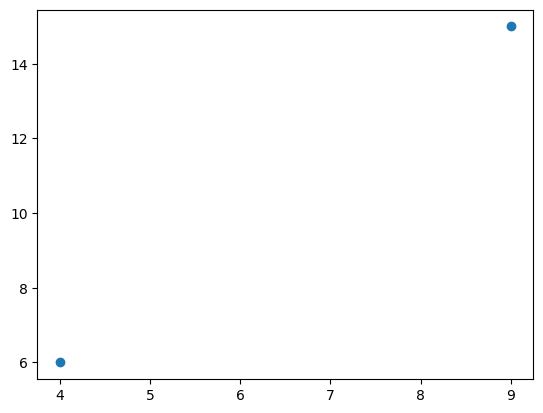

In [ ]:
#plt.plot([3,5],[4,9],'o')
x =[4,9]
y=[6,15]
plt.figure
plt.plot(x,y,'o')

2. Create your own method that outputs the Euclidean distance given two points. Verify the correctness of your method by comparing it with the output value from a built-in python library.

In [ ]:
x = np.array([4,9])
y = np.array((6,15))

eucledian = np.sqrt(np.sum((x-y)**2))
print(eucledian)

from scipy.spatial import distance
builtin = distance.euclidean(x,y)
print(builtin)



6.324555320336759
6.324555320336759


I computed the Eucledian Distance following the mathematical formula, by subtracting the coordinates, squaring the difference, summing them and taking the square root. I verified my results using scipy.spatial.distance.eucledian, and both methods returned the same value. Confirming both methods.

3. Multiply the 2 points you used in step 1 by a factor of 2. Calculate the Euclidean distance between the new points. Please note any interesting observations.

In [ ]:
x = x*2
y = y*2

recal =distance.euclidean(x,y)
print(recal)

12.649110640673518


I observed that doubling the coordinates of the points, makes the Eucledian distance double as well. This shows that the Eucledian distance scales linearly with the coordinates.

4. Create a method that outputs the Manhattan distance given two points. Verify the correctness of your method by comparing it with the output value from a built-in python library.

In [ ]:
x2 = np.array([4,9])
y2 = np.array ([5,18])

manhattan = np.sum (np.abs(x2-y2))
print (manhattan)

from scipy.spatial.distance import cityblock

builtinM = cityblock(x2,y2)
print(builtinM)



10
10


5. Multiply the 2 points you used in step 1 by a factor of 2. Calculate the Manhattan distance between the new points. Please note any interesting observations.

In [ ]:
x2 =x2*2
y2 =y2*2

recalM =cityblock(x2,y2)
print(recalM)

20


After multiplying both points by 2, the Manhattan distance increased proportionally. This shows that Manhattan distance scales linearly with the scaling factor applied to the coordinates, similar to Euclidean distance

## Part Two

6. Create a python script with the following specifications:

    1. Input:
    
        a. An image. This image will contain the template image in it somewhere.

        b. A second image. This will be the template image. Make sure you crop this image exactly from the first image.

    2. Output:

        a. Coordinates of the top left corner of where the template image was found.

        b. An image map showing the normalized differences of the grid search results

Top left corner coordinates found (430, 139)


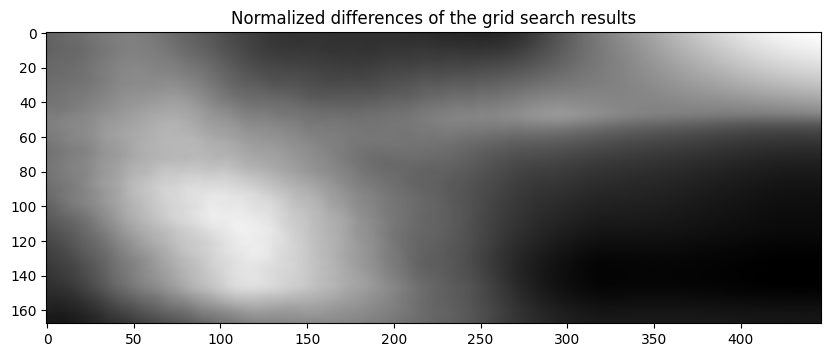

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#loading images in grayscale
image1 = cv2.imread("lab1image.jpeg", cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread("lab2image.jpg", cv2.IMREAD_GRAYSCALE)

#dimensions of the template image
height, width = image2.shape


#normalized differences so the best match is the smallest value
result = cv2.matchTemplate(image1,image2,cv2.TM_CCOEFF_NORMED)
#print(result)


# find min and mac of the local
#min_val and max, lowest and biggest value of the grid
# min and max low, the x, y coordinates of those numbers

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

top_left =min_loc
#output 1
print(f'Top left corner coordinates found {top_left}')

#output 2
plt.figure(figsize=(10,5))
plt.imshow(result, cmap='gray')
plt.title ("Normalized differences of the grid search results")
plt.show()



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Part Three

7. Create 2 normal distributions, each with a different mean and standard deviation.

    a. Determine the KL divergence between the 1st and the 2nd distribution. You may use a standard library to calculate the KL divergence.
    
    b. Determine the KL divergence between the 2nd and the 1st distribution. You may use a standard library to calculate the KL divergence.
    
    c. Screenshot the output for 7a and 7b and discuss why they are not equal. (HINT: you might find [this video](https://www.youtube.com/watch?v=SxGYPqCgJWM) helpful.)

In [ ]:
# create the range where we will work on
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-10, 10, 1000)
#create distributions
# loc = mean, scale = std
distribution1 = stats.norm.pdf(x, loc=3, scale=7)
distribution2 = stats.norm.pdf(x, loc=9, scale=5)


#prob distribution
p= distribution1 /np.sum(distribution1)
#prob distribution 2
q= distribution2 /np.sum(distribution2)

kl_pq= stats.entropy(p, q)
print(f'KL divergence between the 1st and the 2nd distribution: {kl_pq:.5f}')

kl_qp = stats.entropy(q, p)
print(f'KL divergence between the 2nd and the 1s distribution: {kl_qp:.5f}')

KL divergence between the 1st and the 2nd distribution: 0.66179
KL divergence between the 2nd and the 1s distribution: 0.41463


So the Kl divergence values are not equal because Kl divergence is assymetric. The distributions have different means and standard deviations.
KL(1||2) is how inefficient is it to use Distribution 2 to represent Distribution 1.

KL(2||1) on the other hand is how inefficient is it to use Distribution 1 to represent Distribution 2.

So there are two different problems with different values.

